# Exploration

## Initializations

In [1]:
from pint import UnitRegistry
from process_engineering_toolkit.stream import Stream
from process_engineering_toolkit.reactors.pfr import PFR
import matplotlib.pyplot as plt

from process_engineering_toolkit.rate_laws import MassActionRateLaw
from process_engineering_toolkit.reactions import Reactions

## Stream definition

In [2]:
# # This will raise an error as mole fractions must be non-negative
# s1 = Stream("Fresh A", 10, {"A": -1, "B": 0.5}) 
# s2 = Stream("Co-feed", 5, {"B": 0.6, "C": 0.4})

# print(s1.flows)
# print(s2.flows)

In [3]:
# # This will raise an error as compositions must sum to 1
# s1 = Stream("Fresh A", 10, {"A": 0.7, "B": 0.2}) 
# s2 = Stream("Co-feed", 5, {"B": 0.6, "C": 0.4})

# print(s1.flows)
# print(s2.flows)

# inlet = Flow([s1, s2])
# print(inlet.total_flows())

In [4]:
# s1 = Stream("Fresh A", 10, {"A": 0.8, "B": 0.2})
# s2 = Stream("Co-feed", 5, {"B": 0.6, "C": 0.4})

# print(s1.flows)
# print(s2.flows)

## Test case 1: PFR equilibrium conversion, single-reaction system

In [5]:
# Define reaction
reactions = [
    {"equation": "A <-> 2B", "rate_law": "elementary",   "parameters": {"kf": 0.3, "kb": 0.003}},
    ]

# Instantiate reactions object
my_reactions = Reactions(reactions)
print("### Reactions Class ###")
print(f"my_reactions.reactions[0].stoichiometry: {my_reactions.reactions[0].stoichiometry}")
print(f"Species: {my_reactions.species}")
print(f"Stoichiometric Matrix: {my_reactions.SM}")

# Define inlet stream
feed = Stream(name = "feed", total_flow = 20, composition = {"A": 0.6, "I": 0.4})
flows = feed.flows
print("### Stream Class ###")
print(flows)

# Define parameters for PFR reactor
parameters = {
    "phase": "gas",  # or "liquid"
    "operation": "constant_pressure",  # or "constant_density"
    "T": 340,
    "P": 2*101325
}

pfr = PFR(my_reactions, inlet_streams = [feed], parameters = parameters)
print("### PFR Class ###")
print(f"Species: {pfr.species}")
print(f"SM: {pfr.SM}")
print(f"Inlet vector: {pfr.build_inlet_vector()}")

Xeq = pfr.equilibrium_conversion("A")
print("Equilibrium conversion:", Xeq)

### Reactions Class ###
my_reactions.reactions[0].stoichiometry: {'A': -1, 'B': 2}
Species: ['A', 'B']
Stoichiometric Matrix: [[-1.]
 [ 2.]]
### Stream Class ###
{'A': 12.0, 'I': 8.0}
### PFR Class ###
Species: ['A', 'B', 'I']
SM: [[-1.]
 [ 2.]
 [ 0.]]
Inlet vector: [12.  0.  8.]
Equilibrium conversion: 0.5759007764246823


## Test Case 2: PFR volume from target conversion, single-reaction system

Required PFR volume: 0.6316541154157828
Conversion at 5 m^3: 0.5759215841795504


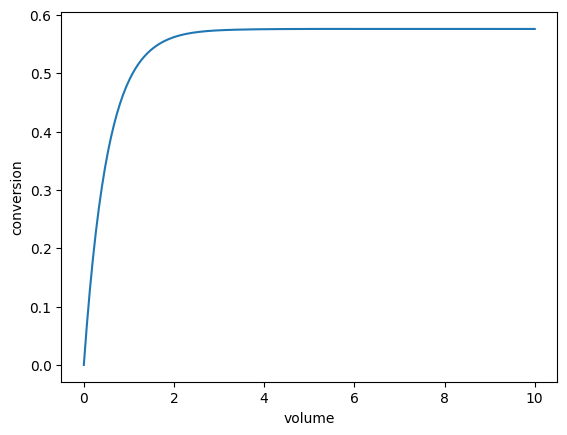

In [6]:
pfr.solve((0,10))
profile = pfr.profile("A", n_points = 300)
# profile["conversion"]
# profile["concentration"]["A"]
# profile["flows"]["B"]
# profile["mole_fraction"]["A"]
# profile["rate"]["R1"]

V_req = pfr.volume_for_conversion("A", 0.4)  # Find volume for 40% conversion
print("Required PFR volume:", V_req)

X = pfr.conversion_at_volume("A", 5)  # Find conversion at 5 m^3
print("Conversion at 5 m^3:", X)


# plt.plot(profile["conversion"], profile["concentration"]["B"])
plt.plot(profile["volume"], profile["conversion"])
plt.xlabel("volume")
plt.ylabel("conversion")
plt.show()


In [6]:
# V = pfr.volume_for_conversion("A", 0.4)

# print("Volume needed in m3: ", V)

sol = pfr.solve(
    V_span=(0,10),
    species="A",
    X_target=0.4
)

V_required = sol.t_events[0][0]

print("Required reactor volume m3:", V_required)
print(sol)

V, X = pfr.conversion_profile("A", (0,10))

FA0:  12.0
Required reactor volume m3: 0.6315592474216057
  message: A termination event occurred.
  success: True
   status: 1
        t: [ 0.000e+00  1.975e-05 ...  5.331e-01  6.316e-01]
        y: [[ 1.200e+01  1.200e+01 ...  7.625e+00  7.200e+00]
            [ 0.000e+00  5.097e-04 ...  8.750e+00  9.600e+00]
            [ 8.000e+00  8.000e+00 ...  8.000e+00  8.000e+00]]
      sol: None
 t_events: [array([ 6.316e-01])]
 y_events: [array([[ 7.200e+00,  9.600e+00,  8.000e+00]])]
     nfev: 36
     njev: 1
      nlu: 6


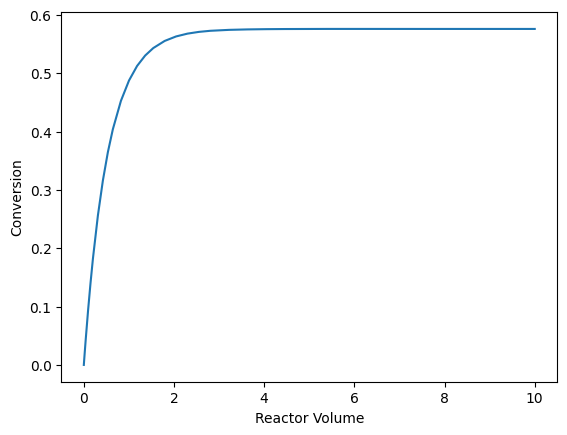

In [7]:
import matplotlib.pyplot as plt

plt.plot(V, X)
plt.xlabel("Reactor Volume")
plt.ylabel("Conversion")
plt.show()